# Docker제거 후, local로 pytest로 교체 : ver8

In [1]:
# Cell 1) imports + run dir 설정
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

def pick_latest_run(runs_root: Path) -> Path:
    candidates = [p for p in runs_root.iterdir() if p.is_dir()]
    if not candidates:
        raise FileNotFoundError(f"No run dirs under: {runs_root}")
    return sorted(candidates, key=lambda p: p.name)[-1]

RUN_DIR = Path('..').resolve()

RESULTS_CSV = RUN_DIR / "results.csv"
TRACES_DIR = RUN_DIR / "traces"
harness_report = Path("../Qwen__Qwen2.5-Coder-7B-Instruct.rollback_exp1_docker_v3-200.json")

print("RUN_DIR =", RUN_DIR)
print("RESULTS_CSV exists?", RESULTS_CSV.exists())
print("TRACES_DIR exists?", TRACES_DIR.exists())

print("run_dir exists:", RUN_DIR.exists(), RUN_DIR)
print("results.csv exists:", RESULTS_CSV.exists())
print("traces dir exists:", TRACES_DIR.exists())
print("harness report exists:", harness_report.exists(), harness_report)

RUN_DIR = /home/dibaeck/workspace/project_IR_sLM_MAS/runs_archive/exp1_qwen2p5_baseline_RE_260310
RESULTS_CSV exists? True
TRACES_DIR exists? True
run_dir exists: True /home/dibaeck/workspace/project_IR_sLM_MAS/runs_archive/exp1_qwen2p5_baseline_RE_260310
results.csv exists: True
traces dir exists: True
harness report exists: True ../Qwen__Qwen2.5-Coder-7B-Instruct.rollback_exp1_docker_v3-200.json


In [2]:
# Cell 2) results load + sanity check

df = pd.read_csv(RESULTS_CSV)
print("results shape:", df.shape)
print("columns:")
print(df.columns.tolist())

display(df.head(3))

results shape: (200, 30)
columns:
['task_id', 'trial_id', 'model', 'prompt_hash', 'taxonomy_version', 'success', 'stage', 'error_type', 'signature', 'returncode', 'gen_elapsed_sec', 'elapsed_sec', 'context_used', 'context_num_files', 'repo_context_preview', 'edit_used', 'edit_parse_ok', 'edit_parse_reason', 'diff_export_ok', 'diff_export_reason', 'format_used', 'format_ok', 'format_reason', 'apply_check_ok', 'apply_check_reason', 'patch_lines_added', 'patch_lines_removed', 'files_changed', 'timestamp', 'seed']


,task_id,trial_id,model,prompt_hash,taxonomy_version,success,stage,error_type,signature,returncode,...,format_used,format_ok,format_reason,apply_check_ok,apply_check_reason,patch_lines_added,patch_lines_removed,files_changed,timestamp,seed
0,astropy__astropy-12907,0,Qwen/Qwen2.5-Coder-7B-Instruct,1d006f36813d2fc095bc8da160e7e87abfd8d05ee8957d...,rollback_exp1_docker_v3,False,EDIT_PARSE,GEN_FAIL,llm_call_fail,NaN,...,NaN,NaN,NaN,NaN,NaN,0,0,0,2026-03-10T16:09:46.656836,42
1,astropy__astropy-14182,0,Qwen/Qwen2.5-Coder-7B-Instruct,323a3b727d26875c53e665ce8dcd10f792793ee5799a7a...,rollback_exp1_docker_v3,False,EDIT_PARSE,GEN_FAIL,invalid_edit_script,-1.0,...,NaN,NaN,NaN,NaN,NaN,0,0,0,2026-03-10T16:14:46.843925,42
2,astropy__astropy-14365,0,Qwen/Qwen2.5-Coder-7B-Instruct,232a841813d672f784b09b1e96ec3c80e68dec2004a896...,rollback_exp1_docker_v3,False,INSTALL,INSTALL_FAIL,editable_install_failed,1.0,...,NaN,NaN,NaN,NaN,NaN,4,2,1,2026-03-10T16:14:49.947849,42


In [3]:
# Cell 3) taxonomy definition
SIGNATURE_TAXONOMY = {
    "editable_install_failed": {
        "tax_stage": "Environment",
        "tax_category": "Setup",
        "tax_subcategory": "EditableInstallFailed",
        "is_infra": True,
        "is_model": False,
    },
    "edit_apply_path_missing": {
        "tax_stage": "Patch_Apply",
        "tax_category": "PathResolution",
        "tax_subcategory": "TargetPathMissing",
        "is_infra": False,
        "is_model": True,
    },
    "edit_apply_range_oob": {
        "tax_stage": "Patch_Apply",
        "tax_category": "Localization",
        "tax_subcategory": "ApplyRangeOutOfBounds",
        "is_infra": False,
        "is_model": True,
    },
    "invalid_edit_script": {
        "tax_stage": "Patch_Parse",
        "tax_category": "PatchSyntax",
        "tax_subcategory": "InvalidEditScript",
        "is_infra": False,
        "is_model": True,
    },
    "llm_call_fail": {
        "tax_stage": "Generation",
        "tax_category": "LLMInvocation",
        "tax_subcategory": "LLMCallFailed",
        "is_infra": False,
        "is_model": False,
    },
    "test_failed": {
        "tax_stage": "Test",
        "tax_category": "SemanticExecution",
        "tax_subcategory": "TestFailed",
        "is_infra": False,
        "is_model": True,
    },
}

# signature가 없거나 taxonomy에 없는 경우를 stage 기준으로 fallback
STAGE_FALLBACK_TAXONOMY = {
    "INSTALL": {
        "tax_stage": "Environment",
        "tax_category": "UnknownInstall",
        "tax_subcategory": "UnknownInstallFailure",
        "is_infra": True,
        "is_model": False,
    },
    "EDIT_PARSE": {
        "tax_stage": "Patch_Parse",
        "tax_category": "UnknownParse",
        "tax_subcategory": "UnknownParseFailure",
        "is_infra": False,
        "is_model": True,
    },
    "EDIT_APPLY": {
        "tax_stage": "Patch_Apply",
        "tax_category": "UnknownApply",
        "tax_subcategory": "UnknownApplyFailure",
        "is_infra": False,
        "is_model": True,
    },
    "TEST": {
        "tax_stage": "Test",
        "tax_category": "UnknownTest",
        "tax_subcategory": "UnknownTestFailure",
        "is_infra": False,
        "is_model": True,
    },
}

In [4]:
# Cell 4) taxonomy assignment helpers

def attach_taxonomy(row):
    sig = str(row.get("signature", "")).strip()
    stg = str(row.get("stage", "")).strip()

    if sig in SIGNATURE_TAXONOMY:
        meta = SIGNATURE_TAXONOMY[sig]
    elif stg in STAGE_FALLBACK_TAXONOMY:
        meta = STAGE_FALLBACK_TAXONOMY[stg]
    else:
        meta = {
            "tax_stage": "Unknown",
            "tax_category": "Unknown",
            "tax_subcategory": "Unknown",
            "is_infra": False,
            "is_model": False,
        }
    return pd.Series(meta)

tax_df = df.apply(attach_taxonomy, axis=1)
df_tax = pd.concat([df.copy(), tax_df], axis=1)

print("df_tax shape:", df_tax.shape)
display(df_tax.head(5))

df_tax shape: (200, 35)


,task_id,trial_id,model,prompt_hash,taxonomy_version,success,stage,error_type,signature,returncode,...,patch_lines_added,patch_lines_removed,files_changed,timestamp,seed,tax_stage,tax_category,tax_subcategory,is_infra,is_model
0,astropy__astropy-12907,0,Qwen/Qwen2.5-Coder-7B-Instruct,1d006f36813d2fc095bc8da160e7e87abfd8d05ee8957d...,rollback_exp1_docker_v3,False,EDIT_PARSE,GEN_FAIL,llm_call_fail,NaN,...,0,0,0,2026-03-10T16:09:46.656836,42,Generation,LLMInvocation,LLMCallFailed,False,False
1,astropy__astropy-14182,0,Qwen/Qwen2.5-Coder-7B-Instruct,323a3b727d26875c53e665ce8dcd10f792793ee5799a7a...,rollback_exp1_docker_v3,False,EDIT_PARSE,GEN_FAIL,invalid_edit_script,-1.0,...,0,0,0,2026-03-10T16:14:46.843925,42,Patch_Parse,PatchSyntax,InvalidEditScript,False,True
2,astropy__astropy-14365,0,Qwen/Qwen2.5-Coder-7B-Instruct,232a841813d672f784b09b1e96ec3c80e68dec2004a896...,rollback_exp1_docker_v3,False,INSTALL,INSTALL_FAIL,editable_install_failed,1.0,...,4,2,1,2026-03-10T16:14:49.947849,42,Environment,Setup,EditableInstallFailed,True,False
3,astropy__astropy-14995,0,Qwen/Qwen2.5-Coder-7B-Instruct,fd14cad64dd3edbd82b7592d7f25cd7092f88230923805...,rollback_exp1_docker_v3,False,EDIT_APPLY,APPLY_FAIL,edit_apply_path_missing,-1.0,...,0,0,0,2026-03-10T16:14:53.928606,42,Patch_Apply,PathResolution,TargetPathMissing,False,True
4,astropy__astropy-6938,0,Qwen/Qwen2.5-Coder-7B-Instruct,c5b32e42610f8f080a47c68fd74b8756f9c425cccd00e2...,rollback_exp1_docker_v3,False,EDIT_APPLY,APPLY_FAIL,edit_apply_path_missing,-1.0,...,0,0,0,2026-03-10T16:14:55.449790,42,Patch_Apply,PathResolution,TargetPathMissing,False,True


In [5]:
# Cell 5) utility functions

def with_ratio(count_df, count_col="count", total=None):
    out = count_df.copy()
    denom = total if total is not None else out[count_col].sum()
    out["ratio"] = out[count_col] / denom
    out["pct"] = (out["ratio"] * 100).round(2)
    return out

def count_by(df_, cols, total=None, ascending=False):
    out = (
        df_.groupby(cols, dropna=False)
           .size()
           .reset_index(name="count")
           .sort_values("count", ascending=ascending)
           .reset_index(drop=True)
    )
    return with_ratio(out, total=total)

TOTAL = len(df_tax)
print("TOTAL =", TOTAL)

TOTAL = 200


In [6]:
# Cell 6) original summaries

stage_summary = count_by(df_tax, ["stage"], total=TOTAL)
error_summary = count_by(df_tax, ["error_type"], total=TOTAL)
sig_summary = count_by(df_tax, ["signature"], total=TOTAL)

print("== stage ==")
display(stage_summary)

print("== error_type ==")
display(error_summary)

print("== signature ==")
display(sig_summary)

== stage ==


,stage,count,ratio,pct
0,INSTALL,122,0.610,61.0
1,EDIT_APPLY,46,0.230,23.0
2,EDIT_PARSE,17,0.085,8.5
3,TEST,15,0.075,7.5


== error_type ==


,error_type,count,ratio,pct
0,INSTALL_FAIL,122,0.610,61.0
1,APPLY_FAIL,46,0.230,23.0
2,GEN_FAIL,17,0.085,8.5
3,TEST_FAIL,15,0.075,7.5


== signature ==


,signature,count,ratio,pct
0,editable_install_failed,122,0.610,61.0
1,edit_apply_path_missing,43,0.215,21.5
2,test_failed,15,0.075,7.5
3,invalid_edit_script,13,0.065,6.5
4,llm_call_fail,4,0.020,2.0
5,edit_apply_range_oob,3,0.015,1.5


In [7]:
# Cell 7) taxonomy summaries

tax_stage_summary = count_by(df_tax, ["tax_stage"], total=TOTAL)
tax_category_summary = count_by(df_tax, ["tax_stage", "tax_category"], total=TOTAL)
tax_subcat_summary = count_by(df_tax, ["tax_stage", "tax_category", "tax_subcategory"], total=TOTAL)

print("== taxonomy stage ==")
display(tax_stage_summary)

print("== taxonomy category ==")
display(tax_category_summary)

print("== taxonomy subcategory ==")
display(tax_subcat_summary)

== taxonomy stage ==


,tax_stage,count,ratio,pct
0,Environment,122,0.610,61.0
1,Patch_Apply,46,0.230,23.0
2,Test,15,0.075,7.5
3,Patch_Parse,13,0.065,6.5
4,Generation,4,0.020,2.0


== taxonomy category ==


,tax_stage,tax_category,count,ratio,pct
0,Environment,Setup,122,0.610,61.0
1,Patch_Apply,PathResolution,43,0.215,21.5
2,Test,SemanticExecution,15,0.075,7.5
3,Patch_Parse,PatchSyntax,13,0.065,6.5
4,Generation,LLMInvocation,4,0.020,2.0
5,Patch_Apply,Localization,3,0.015,1.5


== taxonomy subcategory ==


,tax_stage,tax_category,tax_subcategory,count,ratio,pct
0,Environment,Setup,EditableInstallFailed,122,0.610,61.0
1,Patch_Apply,PathResolution,TargetPathMissing,43,0.215,21.5
2,Test,SemanticExecution,TestFailed,15,0.075,7.5
3,Patch_Parse,PatchSyntax,InvalidEditScript,13,0.065,6.5
4,Generation,LLMInvocation,LLMCallFailed,4,0.020,2.0
5,Patch_Apply,Localization,ApplyRangeOutOfBounds,3,0.015,1.5


In [8]:
# Cell 8) infra/model split

infra_summary = count_by(df_tax, ["is_infra"], total=TOTAL)
model_summary = count_by(df_tax, ["is_model"], total=TOTAL)

print("== infra split ==")
display(infra_summary)

print("== model-related split ==")
display(model_summary)

print("infra count:", int(df_tax["is_infra"].sum()))
print("non-infra count:", int((~df_tax["is_infra"]).sum()))
print("model-related count:", int(df_tax["is_model"].sum()))

== infra split ==


,is_infra,count,ratio,pct
0,True,122,0.61,61.0
1,False,78,0.39,39.0


== model-related split ==


,is_model,count,ratio,pct
0,False,126,0.63,63.0
1,True,74,0.37,37.0


infra count: 122
non-infra count: 78
model-related count: 74


In [9]:
# Cell 9) filtered analysis (exclude infra)

df_no_infra = df_tax[~df_tax["is_infra"]].copy()
TOTAL_NO_INFRA = len(df_no_infra)

print("TOTAL_NO_INFRA =", TOTAL_NO_INFRA)

display(count_by(df_no_infra, ["tax_stage"], total=TOTAL_NO_INFRA))
display(count_by(df_no_infra, ["tax_stage", "tax_category"], total=TOTAL_NO_INFRA))
display(count_by(df_no_infra, ["signature"], total=TOTAL_NO_INFRA))

TOTAL_NO_INFRA = 78


,tax_stage,count,ratio,pct
0,Patch_Apply,46,0.589744,58.97
1,Test,15,0.192308,19.23
2,Patch_Parse,13,0.166667,16.67
3,Generation,4,0.051282,5.13


,tax_stage,tax_category,count,ratio,pct
0,Patch_Apply,PathResolution,43,0.551282,55.13
1,Test,SemanticExecution,15,0.192308,19.23
2,Patch_Parse,PatchSyntax,13,0.166667,16.67
3,Generation,LLMInvocation,4,0.051282,5.13
4,Patch_Apply,Localization,3,0.038462,3.85


,signature,count,ratio,pct
0,edit_apply_path_missing,43,0.551282,55.13
1,test_failed,15,0.192308,19.23
2,invalid_edit_script,13,0.166667,16.67
3,llm_call_fail,4,0.051282,5.13
4,edit_apply_range_oob,3,0.038462,3.85


In [10]:
# Cell 10) cross-tab: observed stage vs taxonomy stage

stage_xtab = pd.crosstab(
    df_tax["stage"],
    df_tax["tax_stage"],
    margins=True
)

display(stage_xtab)

tax_stage,Environment,Generation,Patch_Apply,Patch_Parse,Test,All
stage,,,,,,
EDIT_APPLY,0,0,46,0,0,46
EDIT_PARSE,0,4,0,13,0,17
INSTALL,122,0,0,0,0,122
TEST,0,0,0,0,15,15
All,122,4,46,13,15,200


In [11]:
# Cell 11) inspect unknown mappings

unknown_rows = df_tax[
    (df_tax["tax_stage"] == "Unknown") |
    (df_tax["tax_category"] == "Unknown") |
    (df_tax["tax_subcategory"] == "Unknown")
].copy()

print("unknown rows:", len(unknown_rows))
if len(unknown_rows) > 0:
    display(
        unknown_rows[["stage", "error_type", "signature"]]
        .value_counts()
        .reset_index(name="count")
    )

unknown rows: 0


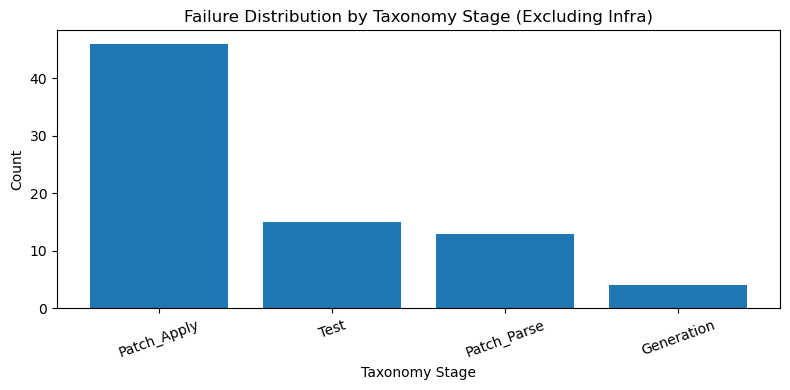

In [12]:
# Cell 13) plot taxonomy stage distribution (excluding infra)

plot_no_infra = count_by(df_no_infra, ["tax_stage"], total=TOTAL_NO_INFRA)

plt.figure(figsize=(8, 4))
plt.bar(plot_no_infra["tax_stage"], plot_no_infra["count"])
plt.title("Failure Distribution by Taxonomy Stage (Excluding Infra)")
plt.xlabel("Taxonomy Stage")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [13]:
# Cell 14) auto-generate report text

def get_count(summary_df, key_col, key):
    matched = summary_df[summary_df[key_col] == key]
    if len(matched) == 0:
        return 0, 0.0
    row = matched.iloc[0]
    return int(row["count"]), float(row["pct"])

env_count, env_pct = get_count(tax_stage_summary, "tax_stage", "Environment")
gen_count, gen_pct = get_count(tax_stage_summary, "tax_stage", "Generation")
parse_count, parse_pct = get_count(tax_stage_summary, "tax_stage", "Patch_Parse")
apply_count, apply_pct = get_count(tax_stage_summary, "tax_stage", "Patch_Apply")

print(
    f"Out of {TOTAL} tasks, "
    f"{env_count} ({env_pct:.1f}%) were categorized as Environment failures, "
    f"{gen_count} ({gen_pct:.1f}%) as Generation failures, "
    f"{parse_count} ({parse_pct:.1f}%) as Patch-Parse failures, and "
    f"{apply_count} ({apply_pct:.1f}%) as Patch-Apply failures."
)

if TOTAL_NO_INFRA > 0:
    no_infra_stage = count_by(df_no_infra, ["tax_stage"], total=TOTAL_NO_INFRA)
    display(no_infra_stage)

Out of 200 tasks, 122 (61.0%) were categorized as Environment failures, 4 (2.0%) as Generation failures, 13 (6.5%) as Patch-Parse failures, and 46 (23.0%) as Patch-Apply failures.


,tax_stage,count,ratio,pct
0,Patch_Apply,46,0.589744,58.97
1,Test,15,0.192308,19.23
2,Patch_Parse,13,0.166667,16.67
3,Generation,4,0.051282,5.13
